https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

## Importing libs

In [139]:
import sys
sys.path.append('..')  # Add parent directory to path
import pandas as pd
import numpy as np
from db_setup.query import query_bigquery_table
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
import seaborn as sns

# Importing Dummyclassifier for baseline model and logistic regression for the actual model
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Importing RandomForestClassifier and XGBClassifier for additional models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Importing Scalers for feature scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Libs to plot AUC-ROC curve
from sklearn.metrics import roc_curve, auc

# Lib for pr-AUC curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# MLflow imports
import mlflow

# NN
import torch
import torch.nn as nn
import torch.optim as optim


# Importing SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

SEED = 42

## MLFlow settings

In [92]:
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/fase_1/Gustavo/mlruns")

In [93]:
# Set the experiment name
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns")
mlflow.set_experiment("Telco-Churn-Prediction")

<Experiment: artifact_location='file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns/582674075718407240', creation_time=1775917117851, experiment_id='582674075718407240', last_update_time=1775917117851, lifecycle_stage='active', name='Telco-Churn-Prediction', tags={}, trace_location=None, workspace='default'>

## Initial Visualization of Data

In [94]:
#df = query_bigquery_table()
df = pd.read_excel(r"C:\Users\vc\Documents\MLENG_FIAP\fase_1\Gustavo\db_setup\Telco_customer_churn.xlsx")
print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [95]:
df.shape

(7043, 33)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Checking for empty, nan, null values and zeros

In [97]:
for column in df.columns:
    empty_count = df[df[column] == ""].shape[0]
    empty_space_count = df[df[column] == " "].shape[0]
    null_count = df[df[column].isnull()].shape[0]
    nan_count = df[df[column].isna()].shape[0]
    zero_count = df[df[column] == 0].shape[0]

    if empty_count > 0:
        print(f'Empty values in {column}: {empty_count}')
    if empty_space_count > 0:
        print(f'Empty spaces in {column}: {empty_space_count}')
    if null_count > 0:
        print(f'Null values in {column}: {null_count}')
    if nan_count > 0:
        print(f'Nans in {column}: {nan_count}')
    if zero_count > 0:
        print(f'Zeros in {column}: {zero_count}')

Zeros in Tenure Months: 11
Empty spaces in Total Charges: 11
Zeros in Churn Value: 5174
Null values in Churn Reason: 5174
Nans in Churn Reason: 5174


### Adjusting Total Charges

In [98]:
df[df['Total Charges'] == " "]['Tenure Months']

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [99]:
mean_total_charges = df[df['Total Charges'] != ' ']['Total Charges'].astype(float).mean()
print(f'Mean Total Charges: {mean_total_charges}')

Mean Total Charges: 2283.3004408418656


In [100]:
median_total_charges = df[df['Total Charges'] != ' ']['Total Charges'].astype(float).median()
print(f'Median Total Charges: {median_total_charges}')

Median Total Charges: 1397.475


(array([1525.,  672.,  512.,  458.,  454.,  316.,  276.,  201.,  194.,
         170.,  179.,  159.,  147.,  162.,  145.,  136.,  159.,  117.,
         121.,  146.,  128.,  108.,  102.,  100.,   83.,   74.,   66.,
          64.,   36.,   22.]),
 array([  18.8       ,  307.66666667,  596.53333333,  885.4       ,
        1174.26666667, 1463.13333333, 1752.        , 2040.86666667,
        2329.73333333, 2618.6       , 2907.46666667, 3196.33333333,
        3485.2       , 3774.06666667, 4062.93333333, 4351.8       ,
        4640.66666667, 4929.53333333, 5218.4       , 5507.26666667,
        5796.13333333, 6085.        , 6373.86666667, 6662.73333333,
        6951.6       , 7240.46666667, 7529.33333333, 7818.2       ,
        8107.06666667, 8395.93333333, 8684.8       ]),
 <BarContainer object of 30 artists>)

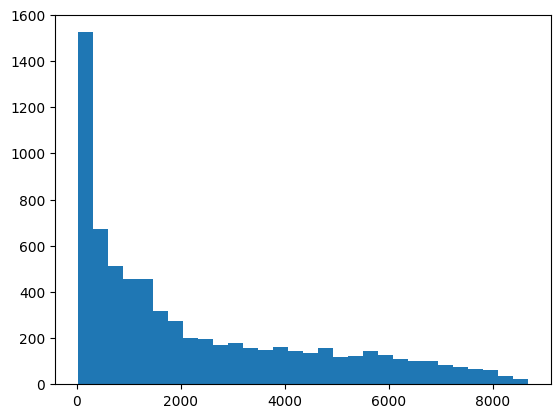

In [101]:
# Histogram of TotalCharges
plt.hist(df[df['Total Charges'] != ' ']['Total Charges'].astype(float), bins=30)

In [102]:
df['Total Charges'] = df['Total Charges'].replace(" ", 0).astype(float)

C:\Users\vc\AppData\Local\Temp\ipykernel_3968\821220724.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total Charges'] = df['Total Charges'].replace(" ", 0).astype(float)


In [103]:
df['Total Charges'] = df['Total Charges'].astype(float)

## Checking feature distribution

In [104]:
for column in df.columns:
    if column == 'CustomerID' or column == 'Churn Value':
        continue
    if df[column].dtype == 'object':
        print(f"Value counts for {column}:")
        print(df[[column, 'Churn Value']].value_counts(normalize=True))
    else:
        print(f"Statistics for {column}:")
        print(df[[column, 'Churn Value']].groupby('Churn Value')[column].describe())
    
    print("\n" + "="*50 + "\n")

Statistics for Count:
              count  mean  std  min  25%  50%  75%  max
Churn Value                                            
0            5174.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
1            1869.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0


Value counts for Country:
Country        Churn Value
United States  0              0.73463
               1              0.26537
Name: proportion, dtype: float64


Value counts for State:
State       Churn Value
California  0              0.73463
            1              0.26537
Name: proportion, dtype: float64


Value counts for City:
City         Churn Value
Los Angeles  0              0.030527
San Diego    0              0.014198
Los Angeles  1              0.012779
San Jose     0              0.011785
Sacramento   0              0.011643
                              ...   
Alpaugh      0              0.000142
Mentone      1              0.000142
Mendota      1              0.000142
Yorkville    1              0.000142
Yermo        1   

In [105]:
df[['Churn Value', 'Churn Label']].value_counts()

Churn Value  Churn Label
0            No             5174
1            Yes            1869
Name: count, dtype: int64

In [106]:
columns = df.columns.tolist()
columns

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

## Correlation matrix

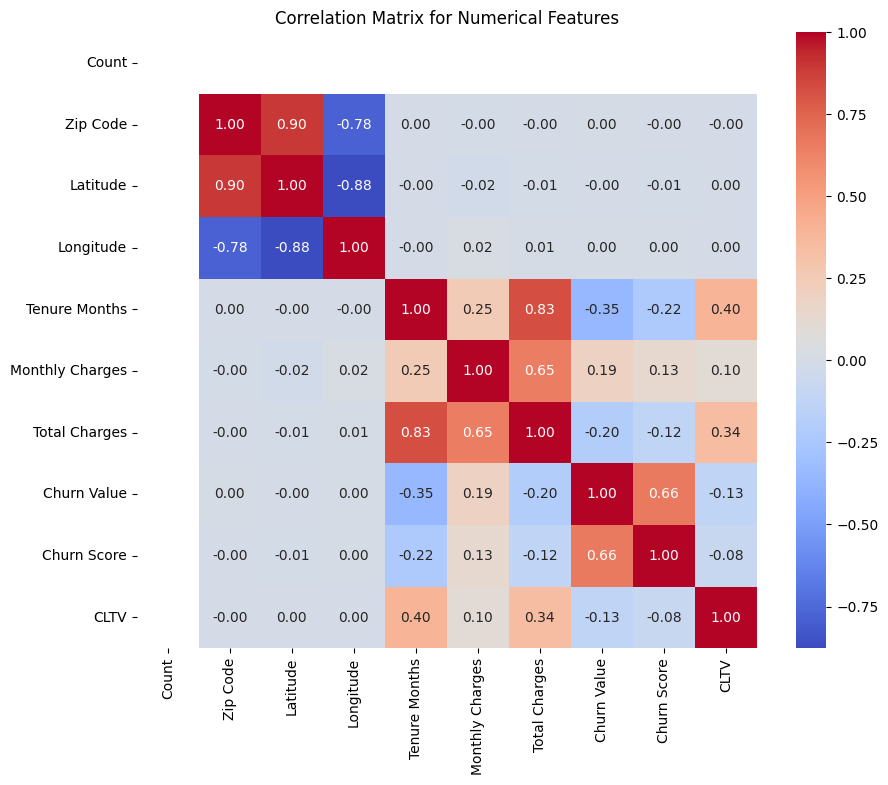

In [107]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Numerical Features')
plt.show()

## Understanding Churn Reason

In [108]:
df['Churn Reason'].value_counts(normalize=True)

Churn Reason
Attitude of support person                   0.102729
Competitor offered higher download speeds    0.101124
Competitor offered more data                 0.086677
Don't know                                   0.082397
Competitor made better offer                 0.074906
Attitude of service provider                 0.072231
Competitor had better devices                0.069556
Network reliability                          0.055110
Product dissatisfaction                      0.054575
Price too high                               0.052434
Service dissatisfaction                      0.047619
Lack of self-service on Website              0.047084
Extra data charges                           0.030498
Moved                                        0.028357
Lack of affordable download/upload speed     0.023542
Limited range of services                    0.023542
Long distance charges                        0.023542
Poor expertise of phone support              0.010701
Poor expertise 

## Dropping columns that won't be used in modeling

In [109]:
df = df.drop(columns=['CustomerID', 'Churn Label', 'Total Charges', 'Churn Reason'])

## Target variable distribution

In [110]:
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)

In [111]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Onehotencoding the categorical variables

In [112]:
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

In [113]:
# Keeping only alphanumeric characters and underscores in column names
df.columns = df.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

In [114]:
# Check which columns are object type
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Object type columns:")
print(object_columns)

# One-hot encoding the categorical variables
df_encoded = pd.get_dummies(df, columns=object_columns, drop_first=True)

print(f"\nOriginal shape: {df.shape}")
print(f"After one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

Object type columns:
['country', 'state', 'city', 'lat_long', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

Original shape: (7043, 29)
After one-hot encoding: (7043, 2815)

New columns: ['count', 'zip_code', 'latitude', 'longitude', 'tenure_months', 'monthly_charges', 'churn', 'churn_score', 'cltv', 'city_Acton', 'city_Adelanto', 'city_Adin', 'city_Agoura Hills', 'city_Aguanga', 'city_Ahwahnee', 'city_Alameda', 'city_Alamo', 'city_Albany', 'city_Albion', 'city_Alderpoint', 'city_Alhambra', 'city_Aliso Viejo', 'city_Alleghany', 'city_Alpaugh', 'city_Alpine', 'city_Alta', 'city_Altadena', 'city_Alturas', 'city_Alviso', 'city_Amador City', 'city_Amboy', 'city_Anaheim', 'city_Anderson', 'city_Angels Camp', 'city_Angelus Oaks', 'city_Angwin', 'city_Annapolis', 'city_Antel

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count              7043 non-null   int64  
 1   country            7043 non-null   object 
 2   state              7043 non-null   object 
 3   city               7043 non-null   object 
 4   zip_code           7043 non-null   int64  
 5   lat_long           7043 non-null   object 
 6   latitude           7043 non-null   float64
 7   longitude          7043 non-null   float64
 8   gender             7043 non-null   object 
 9   senior_citizen     7043 non-null   object 
 10  partner            7043 non-null   object 
 11  dependents         7043 non-null   object 
 12  tenure_months      7043 non-null   int64  
 13  phone_service      7043 non-null   object 
 14  multiple_lines     7043 non-null   object 
 15  internet_service   7043 non-null   object 
 16  online_security    7043 

In [116]:
numerical_features = ['monthly_charges', 'tenure_months']

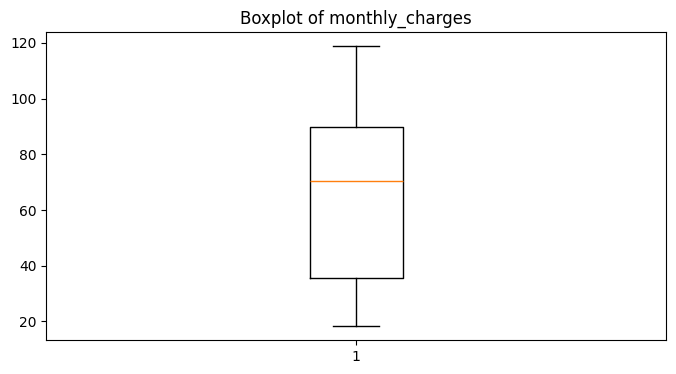

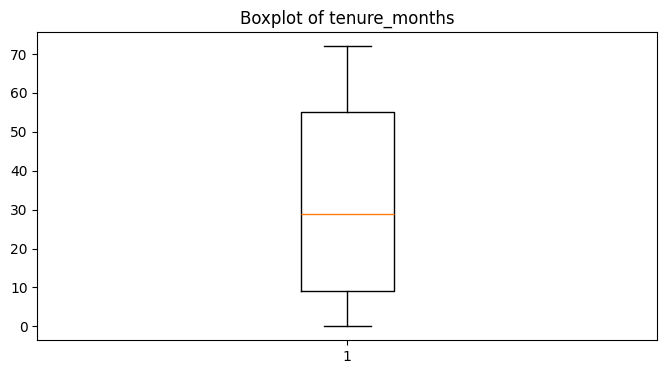

In [117]:
#Checking outliers in the numerical features using boxplots
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_encoded[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [118]:
# adding df to mlflow
df_encoded.to_parquet("./processed_data/df_encoded.parquet")
dataset = mlflow.data.from_pandas(df_encoded, source='./processed_data/df_encoded.parquet', name="df_encoded")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


In [119]:
## Spliting the data into features and target variable
X = df_encoded.drop('churn', axis=1)

X.columns = [col.replace(' ', '_') for col in X.columns]
# keep only alphanumeric characters and underscores in column names
X.columns = X.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

y = df_encoded['churn']

## Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [120]:
# Scaling the numerical features using StandardScaler
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

## Training baseline models

In [140]:
import numpy as np

def train_model(model, X_train, y_train, X_test, y_test, model_name="Model", scaler=None, cv_folds=5):
    # Start MLflow run
    with mlflow.start_run(run_name=f'Experiment - {model_name}'):

        x_cols = X_train.columns

        # Tranforming into numpy arrays to log in mlflow
        if 'xgboost' in model_name.lower():
            X_train = X_train.values
            y_train = y_train.values
            X_test = X_test.values
            y_test = y_test.values

            train_ds = mlflow.data.from_numpy(X_train, targets=y_train, name="train_data")

            test_ds = mlflow.data.from_numpy(X_test, targets=y_test, name="test_data")
        
        else:
            train_ds = mlflow.data.from_pandas(pd.concat([X_train, y_train], axis=1), 
                                           targets=y_train.name, 
                                           name="train_data")

            test_ds = mlflow.data.from_pandas(pd.concat([X_test, y_test], axis=1), 
                                           targets=y_test.name, 
                                           name="test_data")
    
        # Log model parameters
        params = model.get_params()
        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        # Adding datasets
        mlflow.log_input(train_ds, "train_data")
        mlflow.log_input(test_ds, "test_data")
        
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy_train = accuracy_score(y_train, model.predict(X_train))
        precision_train = precision_score(y_train, model.predict(X_train))
        recall_train = recall_score(y_train, model.predict(X_train))
        f1_train = f1_score(y_train, model.predict(X_train))

        accuracy_test = accuracy_score(y_test, y_pred)
        precision_test = precision_score(y_test, y_pred)
        recall_test = recall_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred)

        # Log metrics
        mlflow.log_metric("accuracy_train", accuracy_train)
        mlflow.log_metric("precision_train", precision_train)
        mlflow.log_metric("recall_train", recall_train)
        mlflow.log_metric("f1_score_train", f1_train)
        mlflow.log_metric("accuracy_test", accuracy_test)
        mlflow.log_metric("precision_test", precision_test)
        mlflow.log_metric("recall_test", recall_test)
        mlflow.log_metric("f1_score_test", f1_test)

        # AUC-ROC
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # PR-AUC
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        mlflow.log_metric("pr_auc", pr_auc)
        
        # K-Fold Cross-Validation to detect overfitting
        print(f"\n{'='*60}")
        print(f"K-Fold Cross-Validation (k={cv_folds}) Analysis:")
        print(f"{'='*60}")
        
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
        
        # Define scoring metrics
        scoring = {
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        }
        
        # Prepare data for cross-validation (convert to numpy if needed)
        X_train_cv = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
        y_train_cv = y_train.values if isinstance(y_train, pd.Series) else y_train
        
        # Perform cross-validation
        cv_results = cross_validate(model, X_train_cv, y_train_cv,
                                   cv=skf, scoring=scoring, return_train_score=True)
        
        # Calculate mean and std for each metric
        for metric in scoring.keys():
            train_scores = cv_results[f'train_{metric}']
            test_scores = cv_results[f'test_{metric}']
            
            train_mean = train_scores.mean()
            train_std = train_scores.std()
            test_mean = test_scores.mean()
            test_std = test_scores.std()
            
            # Calculate overfitting indicator (gap between train and test)
            overfitting_gap = train_mean - test_mean
            
            # Log to MLflow
            mlflow.log_metric(f"cv_train_{metric}_mean", train_mean)
            mlflow.log_metric(f"cv_train_{metric}_std", train_std)
            mlflow.log_metric(f"cv_test_{metric}_mean", test_mean)
            mlflow.log_metric(f"cv_test_{metric}_std", test_std)
            mlflow.log_metric(f"cv_{metric}_overfitting_gap", overfitting_gap)
            
            print(f"\n{metric.upper()}:")
            print(f"  Train: {train_mean:.4f} (+/- {train_std:.4f})")
            print(f"  Test:  {test_mean:.4f} (+/- {test_std:.4f})")
            print(f"  Gap:   {overfitting_gap:.4f} (negative = underfitting, positive = overfitting)")
        
        print(f"{'='*60}\n")
        
        # Calculate Churn Cost from False Negatives
        # False Negatives: y_test == 1 (actual churn) and y_pred == 0 (predicted no churn)
        if scaler is not None:
            # Get X_test as DataFrame if it was converted to numpy
            fn_indices = np.where((y_test == 1) & (y_pred == 0))[0]
            fp_indices = np.where((y_test == 0) & (y_pred == 1))[0]
            
            if len(fn_indices) > 0:
                # Get the monthly_charges column index
                monthly_charges_idx = x_cols.get_loc('monthly_charges')
                
                # Extract scaled values for false negatives
                if isinstance(X_test, np.ndarray):
                    scaled_fn_charges = X_test[fn_indices, monthly_charges_idx].reshape(-1, 1)
                else:
                    scaled_fn_charges = X_test.iloc[fn_indices, monthly_charges_idx].values.reshape(-1, 1)
                
                # Create 2-column array (scaler was fitted on 2 features, so we need 2 columns)
                # Second column is zeros since we only care about the first column (monthly_charges)
                scaled_fn_data = np.hstack([scaled_fn_charges, np.zeros((len(fn_indices), 1))])
                
                # Inverse transform to get original values
                unscaled_fn_data = scaler.inverse_transform(scaled_fn_data)
                
                # Sum the monthly charges for false negatives (first column)
                churn_cost = unscaled_fn_data[:, 0].sum()

                # total that can be spent to retain customers that were incorrectly predicted as churned (false positives)
                limit_mkt_cost_fp = 0
                if len(fp_indices) > 0:
                    limit_mkt_cost_fp = churn_cost / len(fn_indices)  # Average cost per false negative

                mlflow.log_metric("false_negatives_count", len(fn_indices))
                mlflow.log_metric("churn_cost_false_negatives", churn_cost)
                mlflow.log_metric("false_positives_count", len(fp_indices))
                mlflow.log_metric("limit_average_marketing_cost_per_false_positive", limit_mkt_cost_fp if len(fp_indices) > 0 else 0)

                print(f"\nChurn Cost Analysis:")
                print(f"False Negatives: {len(fn_indices)}")
                print(f"Churn Cost (sum of monthly charges for FN): ${churn_cost:.2f}")
                print(f"False Positives: {len(fp_indices)}")
                
                print(f"Limit Average Marketing Cost per False Positive (to match FN cost): ${limit_mkt_cost_fp:.2f}")
            else:
                print("\nNo False Negatives found. Churn cost analysis cannot be performed.")
        
        # Log features and coefficients for Logistic Regression
        if hasattr(model, 'coef_'):
            # Extract feature names and coefficients for numpy arrays
            feature_names = X_train.columns.tolist()
            coefficients = model.coef_[0]
            
            # Log individual feature coefficients and odds ratios
            for feature_name, coef in zip(feature_names, coefficients):
                #mlflow.log_param(f"feature_{feature_name}_coef", round(coef, 6))
                # Odds ratio = exp(coefficient)
                odds_ratio = np.exp(coef)
                #mlflow.log_param(f"feature_{feature_name}_odds_ratio", round(odds_ratio, 6))
            
            # Log intercept
            #mlflow.log_param("intercept", round(model.intercept_[0], 6))
            
            # Create and log a summary artifact with feature importance
            feature_summary = pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': coefficients,
                'Odds_Ratio': np.exp(coefficients)
            }).sort_values('Coefficient', ascending=False)
            
            # Save as CSV artifact
            feature_summary.to_csv('./tmp/feature_coefficients.csv', index=False)
            mlflow.log_artifact('./tmp/feature_coefficients.csv', artifact_path='feature_analysis')
            
            print(f"\nFeature Coefficients and Odds Ratios:")
            print(feature_summary)
        
        # Log model
        mlflow.sklearn.log_model(model, name=model_name)

        # Register model in MLflow Model Registry
        mlflow.register_model(f"runs:/{mlflow.active_run().info.run_id}/{model_name}", model_name)
        
        # Print results
        print(f"\n{model.__class__.__name__} Performance:")
        print(f"Accuracy train: {accuracy_train:.4f}")
        print(f'Accuracy test: {accuracy_test:.4f}')
        
        print(f"Precision train: {precision_train:.4f}")
        print(f"Precision test: {precision_test:.4f}")

        print(f"Recall train: {recall_train:.4f}")
        print(f"Recall test: {recall_test:.4f}")
        
        print(f"F1 Score train: {f1_train:.4f}")
        print(f"F1 Score test: {f1_test:.4f}")
        
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
        print(classification_report(y_test, y_pred))

        print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

In [141]:
# Training a Dummy Classifier as a baseline model
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)

train_model(dummy_clf, X_train, y_train, X_test, y_test, model_name="Dummy Classifier", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetr


ACCURACY:
  Train: 0.7346 (+/- 0.0000)
  Test:  0.7346 (+/- 0.0001)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.5000 (+/- 0.0000)
  Test:  0.5000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 374
Churn Cost (sum of monthly charges for FN): $27214.90
False Positives: 0
Limit Average Marketing Cost per False Positive (to match FN cost): $0.00


2026/04/16 22:28:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Dummy Classifier' already exists. Creating a new version of this model...
2026/04/16 22:28:25 WARNING mlflow.tracking._model_registry.fluent: Run with id 91783d9c6d11476ba55db88b300e2717 has no artifacts at artifact path 'Dummy Classifier', registering model based on models:/m-2faf8ae7ad094be795cf471f86bf35af instead



DummyClassifier Performance:
Accuracy train: 0.7346
Accuracy test: 0.7346
Precision train: 0.0000
Precision test: 0.0000
Recall train: 0.0000
Recall test: 0.0000
F1 Score train: 0.0000
F1 Score test: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2654
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

Confusion Matrix:
[[1035    0]
 [ 374    0]]


Created version '15' of model 'Dummy Classifier'.
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\si

In [142]:
## Training a Logistic Regression model
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED)

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression", scaler=scaler)


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod


ACCURACY:
  Train: 0.9254 (+/- 0.0023)
  Test:  0.9207 (+/- 0.0051)
  Gap:   0.0047 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.8639 (+/- 0.0050)
  Test:  0.8568 (+/- 0.0201)
  Gap:   0.0071 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.8532 (+/- 0.0077)
  Test:  0.8428 (+/- 0.0223)
  Gap:   0.0104 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.8585 (+/- 0.0046)
  Test:  0.8493 (+/- 0.0097)
  Gap:   0.0092 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9777 (+/- 0.0012)
  Test:  0.9747 (+/- 0.0034)
  Gap:   0.0030 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 54
Churn Cost (sum of monthly charges for FN): $3398.95
False Positives: 57
Limit Average Marketing Cost per False Positive (to match FN cost): $62.94

Feature Coefficients and Odds Ratios:
                             Feature  Coefficient  Odds_Ratio
2794     internet_service_iber_optic     

2026/04/16 22:33:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression' already exists. Creating a new version of this model...
2026/04/16 22:33:39 WARNING mlflow.tracking._model_registry.fluent: Run with id 909ea91487144d64891a350a53395de1 has no artifacts at artifact path 'Logistic Regression', registering model based on models:/m-2a8dc1fe3d754ac3a3e438af113feb30 instead



LogisticRegression Performance:
Accuracy train: 0.9262
Accuracy test: 0.9212
Precision train: 0.8673
Precision test: 0.8488
Recall train: 0.8522
Recall test: 0.8556
F1 Score train: 0.8596
F1 Score test: 0.8522
ROC-AUC: 0.9745
PR-AUC: 0.9365
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1035
           1       0.85      0.86      0.85       374

    accuracy                           0.92      1409
   macro avg       0.90      0.90      0.90      1409
weighted avg       0.92      0.92      0.92      1409

Confusion Matrix:
[[978  57]
 [ 54 320]]


Created version '12' of model 'Logistic Regression'.


In [124]:
## Training a Logistic Regression model and adding class_weight='balanced' to handle class imbalance
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression with Class Weight", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Churn Cost Analysis:
False Negatives: 26
Churn Cost (sum of monthly charges for FN): $1539.05
False Positives: 99
Limit Average Marketing Cost per False Positive (to match FN cost): $59.19

Feature Coefficients and Odds Ratios:
                             Feature  Coefficient  Odds_Ratio
2794     internet_service_iber_optic     0.605785    1.832691
2812  payment_method_lectronic_check     0.510528    1.666170
2810            paperless_billing_es     0.411616    1.509255
2788               senior_citizen_es     0.349358    1.418157
2792  multiple_lines_o_phone_service     0.296793    1.345536
...                              ...          ...         ...
2803                 tech_support_es    -0.565035    0.568340
2797              online_security_es    -0.610542    0.543057
4                      tenure_months    -1.013415    0.362977
2809                contract_wo_year    -1.029693    0.357116
2790                   dependents_es    -1.488929    0.225614

[2814 rows x 3 columns]


2026/04/16 22:16:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression with Class Weight' already exists. Creating a new version of this model...
2026/04/16 22:17:00 WARNING mlflow.tracking._model_registry.fluent: Run with id 3adb698565e24d109ce8ba97d94912ac has no artifacts at artifact path 'Logistic Regression with Class Weight', registering model based on models:/m-7ec01eb7e47f4413b663f3191536e415 instead



LogisticRegression Performance:
Accuracy train: 0.9089
Accuracy test: 0.9113
Precision train: 0.7752
Precision test: 0.7785
Recall train: 0.9251
Recall test: 0.9305
F1 Score train: 0.8435
F1 Score test: 0.8477
ROC-AUC: 0.9741
PR-AUC: 0.9363
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1035
           1       0.78      0.93      0.85       374

    accuracy                           0.91      1409
   macro avg       0.88      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409

Confusion Matrix:
[[936  99]
 [ 26 348]]


Created version '9' of model 'Logistic Regression with Class Weight'.


## Handling Imbalanced Data with SMOTE

In [125]:
smote = SMOTE(random_state=SEED)

# Convert X_train and y_train to float64/int to avoid casting issues with SMOTE
X_train_float = X_train.astype('float64')
y_train_int = y_train.astype('int')

X_train_smote, y_train_smote = smote.fit_resample(X_train_float, y_train_int)

# Convert back to DataFrame with original column names
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)

logreg_clf_smote = LogisticRegression(max_iter=1000, random_state=SEED)
train_model(logreg_clf_smote, X_train_smote, y_train_smote, X_test, y_test.astype(int), model_name="Logistic Regression with SMOTE", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Churn Cost Analysis:
False Negatives: 30
Churn Cost (sum of monthly charges for FN): $1856.50
False Positives: 87
Limit Average Marketing Cost per False Positive (to match FN cost): $61.88

Feature Coefficients and Odds Ratios:
                             Feature  Coefficient  Odds_Ratio
2794     internet_service_iber_optic     0.706089    2.026053
2788               senior_citizen_es     0.568950    1.766412
2812  payment_method_lectronic_check     0.515404    1.674314
2792  multiple_lines_o_phone_service     0.462256    1.587652
2810            paperless_billing_es     0.404387    1.498383
...                              ...          ...         ...
2803                 tech_support_es    -0.608521    0.544155
2808                contract_ne_year    -0.642965    0.525731
4                      tenure_months    -1.016568    0.361835
2809                contract_wo_year    -1.263054    0.282789
2790                   dependents_es    -1.956731    0.141320

[2814 rows x 3 columns]


2026/04/16 22:17:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression with SMOTE' already exists. Creating a new version of this model...
2026/04/16 22:18:03 WARNING mlflow.tracking._model_registry.fluent: Run with id ec770883ec9b41c6923b4874c3cb3998 has no artifacts at artifact path 'Logistic Regression with SMOTE', registering model based on models:/m-cb9f967f27d941dca61e44c282f4876e instead



LogisticRegression Performance:
Accuracy train: 0.9288
Accuracy test: 0.9170
Precision train: 0.9182
Precision test: 0.7981
Recall train: 0.9415
Recall test: 0.9198
F1 Score train: 0.9297
F1 Score test: 0.8547
ROC-AUC: 0.9747
PR-AUC: 0.9386
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1035
           1       0.80      0.92      0.85       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.92      0.92      0.92      1409

Confusion Matrix:
[[948  87]
 [ 30 344]]


Created version '8' of model 'Logistic Regression with SMOTE'.


## Adding other models

In [126]:
# XGBoost Classifier
xgb_clf = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
train_model(xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [22:18:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Churn Cost Analysis:
False Negatives: 48
Churn Cost (sum of monthly charges for FN): $3210.60
False Positives: 63
Limit Average Marketing Cost per False Positive (to match FN cost): $66.89


2026/04/16 22:18:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost Classifier' already exists. Creating a new version of this model...
2026/04/16 22:18:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 77ea9301f89c427ca1f292238cf1edcb has no artifacts at artifact path 'XGBoost Classifier', registering model based on models:/m-13e498510a284cef9b52bca09f961c21 instead



XGBClassifier Performance:
Accuracy train: 1.0000
Accuracy test: 0.9212
Precision train: 1.0000
Precision test: 0.8380
Recall train: 1.0000
Recall test: 0.8717
F1 Score train: 1.0000
F1 Score test: 0.8545
ROC-AUC: 0.9811
PR-AUC: 0.9536
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1035
           1       0.84      0.87      0.85       374

    accuracy                           0.92      1409
   macro avg       0.90      0.91      0.90      1409
weighted avg       0.92      0.92      0.92      1409

Confusion Matrix:
[[972  63]
 [ 48 326]]


Created version '7' of model 'XGBoost Classifier'.


In [127]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=SEED)
train_model(rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier", scaler=scaler)


Churn Cost Analysis:
False Negatives: 73
Churn Cost (sum of monthly charges for FN): $4886.80
False Positives: 36
Limit Average Marketing Cost per False Positive (to match FN cost): $66.94


2026/04/16 22:18:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Random Forest Classifier' already exists. Creating a new version of this model...
2026/04/16 22:18:47 WARNING mlflow.tracking._model_registry.fluent: Run with id a4f14d21801949d3986a68c50ac045ac has no artifacts at artifact path 'Random Forest Classifier', registering model based on models:/m-8cc7dcd921f4483f982ab3d1b672253d instead



RandomForestClassifier Performance:
Accuracy train: 1.0000
Accuracy test: 0.9226
Precision train: 1.0000
Precision test: 0.8932
Recall train: 1.0000
Recall test: 0.8048
F1 Score train: 1.0000
F1 Score test: 0.8467
ROC-AUC: 0.9623
PR-AUC: 0.9118
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1035
           1       0.89      0.80      0.85       374

    accuracy                           0.92      1409
   macro avg       0.91      0.89      0.90      1409
weighted avg       0.92      0.92      0.92      1409

Confusion Matrix:
[[999  36]
 [ 73 301]]


Created version '6' of model 'Random Forest Classifier'.


In [128]:
# Random Search CV for Hyperparameter Tuning of XGBoost

random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf_random = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(estimator=xgb_clf_random, param_distributions=random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

random_search.fit(X_train.values, y_train.astype(int))

print(f"Best parameters found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [22:21:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [129]:
# Using the best estimator from random search to train and evaluate
best_xgb_clf = random_search.best_estimator_
train_model(best_xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier with Random Search CV", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [22:21:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Churn Cost Analysis:
False Negatives: 40
Churn Cost (sum of monthly charges for FN): $2574.95
False Positives: 60
Limit Average Marketing Cost per False Positive (to match FN cost): $64.37


2026/04/16 22:22:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost Classifier with Random Search CV' already exists. Creating a new version of this model...
2026/04/16 22:22:19 WARNING mlflow.tracking._model_registry.fluent: Run with id 999a75c5c3154110812b55ad59b3c8ae has no artifacts at artifact path 'XGBoost Classifier with Random Search CV', registering model based on models:/m-30a90a60098f48519ec796a0abfe9936 instead



XGBClassifier Performance:
Accuracy train: 0.9418
Accuracy test: 0.9290
Precision train: 0.8867
Precision test: 0.8477
Recall train: 0.8950
Recall test: 0.8930
F1 Score train: 0.8908
F1 Score test: 0.8698
ROC-AUC: 0.9828
PR-AUC: 0.9582
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1035
           1       0.85      0.89      0.87       374

    accuracy                           0.93      1409
   macro avg       0.90      0.92      0.91      1409
weighted avg       0.93      0.93      0.93      1409

Confusion Matrix:
[[975  60]
 [ 40 334]]


Created version '7' of model 'XGBoost Classifier with Random Search CV'.


In [130]:
# Random search for Random Forest Classifier
rf_random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_clf_random = RandomForestClassifier(random_state=SEED)
rf_random_search = RandomizedSearchCV(estimator=rf_clf_random, param_distributions=rf_random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

rf_random_search.fit(X_train, y_train.astype(int))
print(f"Best parameters found for Random Forest: {rf_random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found for Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}


In [131]:
# Training a Random Forest Classifier with best parameters from random search
best_rf_clf = rf_random_search.best_estimator_
train_model(best_rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier with Random Search CV", scaler=scaler)



Churn Cost Analysis:
False Negatives: 162
Churn Cost (sum of monthly charges for FN): $10536.75
False Positives: 21
Limit Average Marketing Cost per False Positive (to match FN cost): $65.04


2026/04/16 22:23:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Random Forest Classifier with Random Search CV' already exists. Creating a new version of this model...
2026/04/16 22:23:36 WARNING mlflow.tracking._model_registry.fluent: Run with id 9ccdfbe2eb544272a84846e58935c216 has no artifacts at artifact path 'Random Forest Classifier with Random Search CV', registering model based on models:/m-bd878ed5720e45bbb5064208842334d1 instead
Created version '6' of model 'Random Forest Classifier with Random Search CV'.



RandomForestClassifier Performance:
Accuracy train: 0.9246
Accuracy test: 0.8701
Precision train: 0.9677
Precision test: 0.9099
Recall train: 0.7405
Recall test: 0.5668
F1 Score train: 0.8390
F1 Score test: 0.6985
ROC-AUC: 0.9492
PR-AUC: 0.8925
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1035
           1       0.91      0.57      0.70       374

    accuracy                           0.87      1409
   macro avg       0.89      0.77      0.81      1409
weighted avg       0.87      0.87      0.86      1409

Confusion Matrix:
[[1014   21]
 [ 162  212]]


## Creating Neural Network with PyTorch

In [153]:


from pyexpat import model


def train_and_evaluate_nn(X_train, y_train, X_test, y_test, model_name="Neural Network", 
                          num_epochs=100, patience=10, min_delta=0.0001, val_split=0.2,
                          learning_rate=0.001, batch_size=32, log_to_mlflow=True, 
                          NN=None, scaler=None):
    """
    Train and evaluate a neural network with logit-based loss and proper probability conversion.
    """
    from torch.utils.data import DataLoader, TensorDataset
    
    if NN is None:
        raise ValueError("Please provide a Neural Network class (e.g., ChurnNetWOSig)")

    # Store column names for cost analysis
    x_test_cols = X_test.columns
    
    # Ensure data is float32
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')
    
    # Create validation split
    val_size = int(len(X_train) * val_split)
    X_train_split = X_train.iloc[:-val_size]
    X_val_split = X_train.iloc[-val_size:]
    y_train_split = y_train.iloc[:-val_size]
    y_val_split = y_train.iloc[-val_size:]
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_split.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_split.values, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_split.values, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    # Start MLflow Run
    run_context = mlflow.start_run(run_name=f'Experiment - {model_name}') if log_to_mlflow else nullcontext()
    
    with run_context:
        # Dynamic pos_weight calculation for imbalance
        num_pos = torch.sum(y_train_tensor == 1).float()
        num_neg = torch.sum(y_train_tensor == 0).float()
        pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)])

        # BCEWithLogitsLoss expects raw logits from the model
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        input_dim = X_train.shape[1]
        model = NN(input_dim)
        # Equivalent to L2 regularization
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)
        
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        epochs_trained = 0
        
        # --- Training Loop ---
        for epoch in range(num_epochs):
            model.train()
            epoch_train_loss = 0.0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            
            # --- Validation ---
            model.eval()
            epoch_val_loss = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    val_logits = model(X_batch)
                    val_loss = criterion(val_logits, y_batch)
                    epoch_val_loss += val_loss.item()
            
            avg_train_loss = epoch_train_loss / len(train_loader)
            avg_val_loss = epoch_val_loss / len(val_loader)
            epochs_trained = epoch + 1

            # Early stopping
            if avg_val_loss < best_val_loss - min_delta:
                best_val_loss = avg_val_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if (epoch+1) % 5 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}')
                model.load_state_dict(best_model_state)
                break

        # --- Evaluation ---
        model.eval()
        y_pred_prob_list = []
        with torch.no_grad():
            for X_batch, _ in test_loader:
                logits = model(X_batch)
                # Convert logits to probabilities via Sigmoid
                probs = torch.sigmoid(logits).cpu().numpy()
                y_pred_prob_list.append(probs)
        
        y_pred_prob = np.vstack(y_pred_prob_list).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        pr_auc = average_precision_score(y_test, y_pred_prob)
        
        # Churn Cost Analysis
        if scaler is not None:
            fn_indices = np.where((y_test.values.flatten() == 1) & (y_pred == 0))[0]
            fp_indices = np.where((y_test.values.flatten() == 0) & (y_pred == 1))[0]
            
            if len(fn_indices) > 0:
                monthly_charges_idx = x_test_cols.get_loc('monthly_charges')
                scaled_fn_charges = X_test.iloc[fn_indices, monthly_charges_idx].values.reshape(-1, 1)
                # Dummy array for inverse transform (assumes scaler expects 2 features)
                dummy_data = np.hstack([scaled_fn_charges, np.zeros((len(fn_indices), 1))])
                unscaled_data = scaler.inverse_transform(dummy_data)
                churn_cost = unscaled_data[:, 0].sum()
                
                print(f"\nChurn Cost Analysis:")
                print(f"False Negatives: {len(fn_indices)} | Cost: ${churn_cost:.2f}")
                print(f"False Positives: {len(fp_indices)}")

        print(f'\n{model_name} Results:')
        print(f'Accuracy: {accuracy:.4f} | Recall: {recall:.4f} | ROC-AUC: {roc_auc:.4f}')

        if log_to_mlflow:
            mlflow.log_params({"lr": learning_rate, "batch_size": batch_size, "patience": patience})
            mlflow.log_metrics({"accuracy": accuracy, "recall": recall, "roc_auc": roc_auc, "f1": f1})
            mlflow.pytorch.log_model(model, "model")

    return {'model': model, 'accuracy': accuracy, 'recall': recall, 'roc_auc': roc_auc, 'y_pred_prob': y_pred_prob}

In [154]:
class SimpleChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleChurnNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

In [155]:
# Train the neural network
nn_results = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test, 
                                    model_name="Neural Network with SMOTE", NN=SimpleChurnNN, scaler=scaler)


Epoch [5/100], Train Loss: 1.0165, Val Loss: 0.5220
Epoch [10/100], Train Loss: 1.0165, Val Loss: 0.5220


2026/04/16 22:59:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 11. Best Val Loss: 0.5220

Neural Network with SMOTE Results:
Accuracy: 0.2654 | Recall: 1.0000 | ROC-AUC: 0.5000


2026/04/16 22:59:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [134]:
class LogisticRegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionNN, self).__init__()
        # One linear layer: input_dim -> 1 output
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        # Sigmoid squashes the output between 0 and 1 (probability)
        return torch.sigmoid(self.linear(x))

In [135]:
nn_results_logreg = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="Logistic Regression NN with SMOTE", NN=LogisticRegressionNN, scaler=scaler)

Epoch [5/100], Train Loss: 1.0165, Val Loss: 0.5220
Epoch [10/100], Train Loss: 1.0165, Val Loss: 0.5220

Early stopping triggered at epoch 11. Best validation loss: 0.5220
Training completed. Total epochs trained: 11

No False Negatives found. Churn cost analysis cannot be performed.

Logistic Regression NN with SMOTE Performance:
Accuracy: 0.2654
Precision: 0.2654
Recall: 1.0000
F1 Score: 0.4195
ROC-AUC: 0.5000
PR-AUC: 0.2654


2026/04/16 22:25:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 22:25:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'Logistic Regression NN with SMOTE' already exists. Creating a new version of this model...
2026/04/16 22:25:24 WARNING mlflow.tracking._model_registry.fluent: Run with id 0ac21d6cc2644a6e96ad32d5c70ca99e has no artifacts at artifact path 'Logistic Regression NN with SMOTE', registering model based on models:/m-263efeda00a5453a849e8d1d88423a32 instead
Created version '6' of model 'Logistic Regression NN with SMOTE'.


In [136]:
nn_results_logreg = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="Logistic Regression NN", NN=LogisticRegressionNN, scaler=scaler)

Epoch [5/100], Train Loss: 1.1935, Val Loss: 1.1930
Epoch [10/100], Train Loss: 1.1936, Val Loss: 1.1930

Early stopping triggered at epoch 11. Best validation loss: 1.1930
Training completed. Total epochs trained: 11

No False Negatives found. Churn cost analysis cannot be performed.

Logistic Regression NN Performance:
Accuracy: 0.2654
Precision: 0.2654
Recall: 1.0000
F1 Score: 0.4195
ROC-AUC: 0.5000
PR-AUC: 0.2654


2026/04/16 22:25:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 22:25:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'Logistic Regression NN' already exists. Creating a new version of this model...
2026/04/16 22:26:00 WARNING mlflow.tracking._model_registry.fluent: Run with id 28045b9d4060496589524c1d905fd8ce has no artifacts at artifact path 'Logistic Regression NN', registering model based on models:/m-2e29a8c6d0524d3589f3aa65559aad09 instead
Created version '6' of model 'Logistic Regression NN'.


In [145]:

class ChurnNet(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNet, self).__init__()
        # Increasing capacity slightly
        self.l1 = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2) # Prevents overfitting
        self.l2 = nn.Linear(16, 8)
        self.l3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.dropout(x)
        x = self.relu(self.l2(x))
        return self.sigmoid(self.l3(x))

In [146]:
nn_results_churnnet = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="ChurnNet with SMOTE", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 1.0155, Val Loss: 0.5220
Epoch [10/100], Train Loss: 0.8668, Val Loss: 1.1550

Early stopping triggered at epoch 11. Best validation loss: 0.5220
Training completed. Total epochs trained: 11

Churn Cost Analysis:
False Negatives: 374
Churn Cost (sum of monthly charges for FN): $27214.90
False Positives: 0
Limit Average Marketing Cost per False Positive (to match FN cost): $0.00

ChurnNet with SMOTE Performance:
Accuracy: 0.7346
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2654


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/04/16 22:42:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 22:42:51 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'ChurnNet with SMOTE' already exists. Creating a new version of this model...
2026

In [147]:
class ChurnNetWOSig(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNetWOSig, self).__init__()
        # Wider first layer to capture more feature interactions
        self.l1 = nn.Linear(input_dim, 16)
        # Using LeakyReLU to prevent "dead" neurons in small networks
        self.relu = nn.LeakyReLU(0.01) 
        self.dropout = nn.Dropout(0.2) 
        self.l2 = nn.Linear(16, 8)
        self.l3 = nn.Linear(8, 1)
        # NO SIGMOID HERE - We use BCEWithLogitsLoss for stability
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.dropout(x)
        x = self.relu(self.l2(x))
        # Returns raw logits (-inf to +inf)
        return self.l3(x)

In [151]:
nn_results_churnnet = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="ChurnNet with SMOTE", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 0.8675, Val Loss: 1.1550
Epoch [10/100], Train Loss: 0.8674, Val Loss: 1.1550


2026/04/16 22:56:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 11. Best Val Loss: 1.1550

Churn Cost Analysis:
False Negatives: 374 | Cost: $27214.90
False Positives: 0

ChurnNet with SMOTE Results:
Accuracy: 0.7346 | Recall: 0.0000 | ROC-AUC: 0.5000


2026/04/16 22:56:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [156]:
nn_results_churnnet = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="ChurnNet", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 1.0172, Val Loss: 1.0187
Epoch [10/100], Train Loss: 1.0174, Val Loss: 1.0187


2026/04/16 23:00:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 11. Best Val Loss: 1.0187

Churn Cost Analysis:
False Negatives: 374 | Cost: $27214.90
False Positives: 0

ChurnNet Results:
Accuracy: 0.7346 | Recall: 0.0000 | ROC-AUC: 0.5000


2026/04/16 23:00:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [162]:
import torch.nn.functional as F

class GatedLinearUnit(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim * 2) # Double size for gating

    def forward(self, x):
        x = self.fc(x)
        # Split in half: one for values, one for the gate
        x, gate = torch.split(x, x.shape[-1] // 2, dim=-1)
        return x * torch.sigmoid(gate)
    
class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.glu = GatedLinearUnit(input_dim, output_dim)
        self.scale = torch.sqrt(torch.tensor([0.5])) # Scaler for residual connection

    def forward(self, x):
        # Simplest version: GLU + Residual Connection
        x_out = self.glu(x)
        return (x + x_out) * self.scale if x.shape == x_out.shape else x_out

class AttentiveTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        # Sparsemax isn't built into PyTorch, but can be imported or simplified
        # For this example, we'll assume a Sparsemax logic

    def forward(self, x, prior_scales):
        x = self.bn(self.fc(x))
        x = x * prior_scales # Don't look at what we already used too much
        # return sparsemax(x)
        return F.softmax(x, dim=-1) # Placeholder for Sparsemax

class AttentiveTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        # Sparsemax isn't built into PyTorch, but can be imported or simplified
        # For this example, we'll assume a Sparsemax logic

    def forward(self, x, prior_scales):
        x = self.bn(self.fc(x))
        x = x * prior_scales # Don't look at what we already used too much
        # return sparsemax(x)
        return F.softmax(x, dim=-1) # Placeholder for Sparsemax


class TabNetSimplified(nn.Module):
    def __init__(self, input_dim, output_dim, n_steps=3):
        super().__init__()
        self.n_steps = n_steps
        self.input_dim = input_dim
        
        # Transformers
        self.feature_transformer = FeatureTransformer(input_dim, 16)
        self.attentive_transformer = AttentiveTransformer(16, input_dim)
        
        self.final_mapping = nn.Linear(16, output_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        prior_scales = torch.ones((batch_size, self.input_dim))
        out_accumulator = 0
        
        # Step 0: Initial processing
        x_processed = self.feature_transformer(x)
        
        for step in range(self.n_steps):
            # 1. Decide which features to look at
            mask = self.attentive_transformer(x_processed, prior_scales)
            
            # 2. Apply mask to raw features
            masked_x = x * mask
            
            # 3. Process the masked features
            step_output = self.feature_transformer(masked_x)
            
            # 4. Accumulate results
            out_accumulator += F.relu(step_output)
            
            # 5. Update priors (so we look at NEW things in the next step)
            prior_scales = prior_scales * (1.5 - mask) # Simple relaxation logic
            x_processed = step_output
            
        return self.final_mapping(out_accumulator)

In [165]:

def train_and_evaluate_tabnet(X_train, y_train, X_test, y_test, model_name="TabNet_Churn", 
                              num_epochs=100, patience=15, learning_rate=0.02, 
                              batch_size=128, n_steps=3, log_to_mlflow=True, 
                              NN=None, scaler=None):
    """
    Specialized training function for TabNet architecture with sequential attention.
    """
    from torch.utils.data import DataLoader, TensorDataset
    
    # Device configuration (Uses your NVIDIA RTX 2000)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Column names for cost analysis
    x_test_cols = X_test.columns
    
    # Pre-process data
    X_train_f32 = X_train.astype('float32')
    X_test_f32 = X_test.astype('float32')
    
    # Tensors and DataLoaders
    X_train_tensor = torch.tensor(X_train_f32.values).to(device)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
    X_test_tensor = torch.tensor(X_test_f32.values).to(device)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)

    # Calculate pos_weight for imbalance
    num_pos = torch.sum(y_train_tensor == 1).float()
    num_neg = torch.sum(y_train_tensor == 0).float()
    pos_weight = (num_neg / (num_pos + 1e-8)).to(device)
    print(pos_weight)

    # Initialize model
    input_dim = X_train.shape[1]
    model = NN(input_dim=input_dim, output_dim=1, n_steps=n_steps).to(device)
    
    # TabNet often performs better with Adam and a slightly higher learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_loss = float('inf')
    patience_counter = 0
    epochs_trained = 0

    print(f"Starting TabNet Training...")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            
            # Prevent exploding gradients in attention blocks
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        epochs_trained += 1

        # Early Stopping logic based on Training Loss (simplified)
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break

    # --- Evaluation ---
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        y_pred_prob = torch.sigmoid(test_logits).cpu().numpy().flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    roc_auc = auc(*roc_curve(y_test, y_pred_prob)[0:2])

    print(f"\n--- {model_name} Final Performance ---")
    print(f"Accuracy: {accuracy:.4f} | Recall: {recall:.4f} | ROC-AUC: {roc_auc:.4f}")

    # Log to MLflow
    if log_to_mlflow:
        with mlflow.start_run(run_name=model_name):
            mlflow.log_params({"lr": learning_rate, "n_steps": n_steps, "batch_size": batch_size})
            mlflow.log_metrics({"accuracy": accuracy, "recall": recall, "roc_auc": roc_auc})
            mlflow.pytorch.log_model(model, "tabnet_model")

    return {
        'model': model,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'auc': roc_auc
    }

In [166]:
# Assuming X_train_scaled, y_train, etc. are ready
results = train_and_evaluate_tabnet(
    X_train, y_train, 
    X_test, y_test, 
    NN=TabNetSimplified, # The class you built
    n_steps=5,           # Number of sequential decision steps
    learning_rate=0.01,
    scaler=scaler
)

Using device: cpu
tensor(2.7686)
Starting TabNet Training...


KeyboardInterrupt: 

In [ ]:
import nbformat
from nbformat import read, NO_CONVERT

def extract_code_from_notebook(notebook_path):
    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = nbformat.read(f, as_version=NO_CONVERT)
    
    code_cells = [cell for cell in notebook.cells if cell.cell_type == 'code']
    code_blocks = []
    
    for cell in code_cells:
        # Processa cada célula
        cell_lines = cell.source.splitlines()
        # Remove linhas vazias e comentários
        filtered_lines = [line for line in cell_lines if line.strip() and not line.strip().startswith('#')]
        # Se houver linhas, adiciona o bloco
        if filtered_lines:
            code_blocks.append('\n'.join(filtered_lines))
    
    # Junta os blocos com quebras de linha (3 quebras = espaçamento claro)
    return '\n\n\n'.join(code_blocks)

code = extract_code_from_notebook('eda.ipynb')
with open('eda.py', 'w', encoding='utf-8') as f:
    f.write(code)

    